In [1]:
import sqlite3
import pandas as pd

conn=sqlite3.connect("../data/analytics.db")

In [5]:
# Top 10 products by revenue
query="""
SELECT 
    p.name as product_name, 
    p.brand, 
    p.category, 
    SUM(ti.quantity*ti.price) as revenue,
    SUM(ti.quantity) as total_units_sold
FROM transaction_items ti
JOIN products p ON ti.product_id = p.product_id
GROUP BY p.product_id
ORDER BY revenue DESC
LIMIT 10;"""
top_products=pd.read_sql(query, conn)
top_products

,product_name,brand,category,revenue,total_units_sold
0,Product 304,Brand 20,Beverages,4875.12,204
1,Product 151,Brand 21,Produce,4834.16,202
2,Product 30,Brand 6,Produce,4766.00,200
3,Product 73,Brand 31,Bakery,4636.92,187
4,Product 220,Brand 7,Pantry,4613.47,191
5,Product 327,Brand 3,Beverages,4602.17,215
6,Product 9,Brand 17,Produce,4584.21,187
7,Product 161,Brand 45,Beverages,4577.45,185
8,Product 424,Brand 13,Produce,4518.87,193
9,Product 228,Brand 8,Meat,4514.08,185


In [13]:
# Top 5 categories by revenue
query="""
SELECT p.category, SUM(ti.quantity*ti.price) as revenue
FROM transaction_items ti
JOIN products p ON ti.product_id = p.product_id
GROUP BY p.category
ORDER BY revenue DESC;
"""
top_categories=pd.read_sql(query, conn)
top_categories

,category,revenue
0,Beverages,196734.42
1,Meat,195488.65
2,Frozen,170974.42
3,Produce,165726.44
4,Dairy,137054.22
5,Bakery,124421.21
6,Pantry,115054.30


In [16]:
# Profitability Analysis
query="""
SELECT 
    p.category, 
    SUM(ti.quantity*(ti.price - p.cost)) as profit,
    SUM(ti.quantity*ti.price) as revenue,
    ROUND((SUM(ti.quantity*(ti.price - p.cost))*100.0)/SUM(ti.quantity*ti.price),2) as profit_margin
FROM transaction_items ti
JOIN products p ON ti.product_id = p.product_id
GROUP BY p.category
ORDER BY profit DESC;
"""
profitability=pd.read_sql(query, conn)
profitability


,category,profit,revenue,profit_margin
0,Meat,86359.95,195488.65,44.18
1,Beverages,79777.64,196734.42,40.55
2,Frozen,65239.86,170974.42,38.16
3,Produce,62984.84,165726.44,38.01
4,Bakery,52768.13,124421.21,42.41
5,Dairy,47832.90,137054.22,34.90
6,Pantry,45518.21,115054.30,39.56


In [17]:
# Category Contribution to Total Revenue
top_categories['percent_contribution'] = (top_categories['revenue'] / top_categories['revenue'].sum() * 100).round(2)
top_categories.sort_values(by='percent_contribution', ascending=False)

,category,revenue,percent_contribution
0,Beverages,196734.42,17.80
1,Meat,195488.65,17.68
2,Frozen,170974.42,15.47
3,Produce,165726.44,14.99
4,Dairy,137054.22,12.40
5,Bakery,124421.21,11.26
6,Pantry,115054.30,10.41


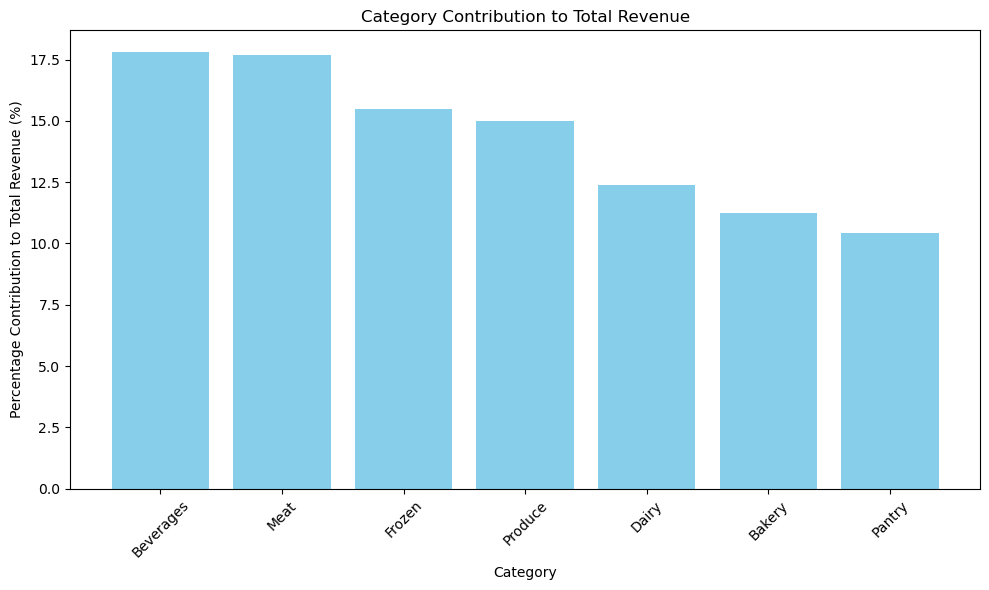

In [ ]:
# Category Contribution to Total Revenue Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_categories['category'], top_categories['percent_contribution'], color='skyblue')
plt.xlabel('Category')
plt.ylabel('Percentage Contribution to Total Revenue (%)')
plt.title('Category Contribution to Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

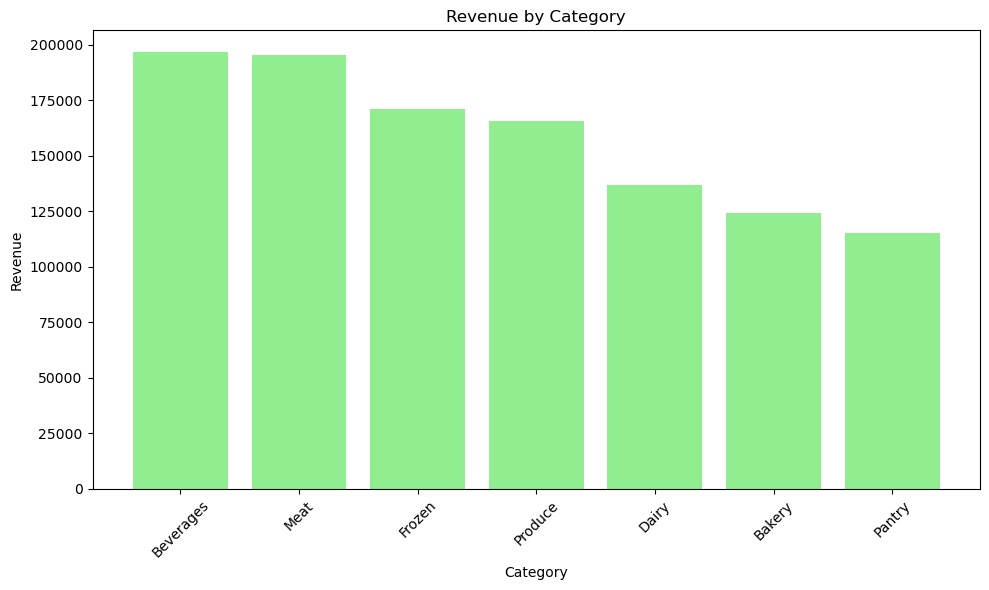

In [19]:
# Category Revenue Visualization
plt.figure(figsize=(10,6))
plt.bar(top_categories['category'], top_categories['revenue'], color='lightgreen')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
query="""
SELECT * FROM products where base_price<cost;
"""
underpriced_products=pd.read_sql(query, conn)
underpriced_products

,product_id,barcode,name,brand,category,pack_size,base_price,cost
0,3,100000000003,Product 3,Brand 36,Produce,200g,3.66,4.93
1,4,100000000004,Product 4,Brand 17,Frozen,1000g,4.64,10.03
2,20,100000000020,Product 20,Brand 1,Produce,500g,8.25,8.38
3,23,100000000023,Product 23,Brand 37,Pantry,1000g,7.23,14.51
4,32,100000000032,Product 32,Brand 1,Meat,500g,10.29,14.42
...,...,...,...,...,...,...,...,...
138,474,100000000474,Product 474,Brand 34,Produce,200g,7.64,11.76
139,480,100000000480,Product 480,Brand 25,Produce,400g,3.37,11.98
140,481,100000000481,Product 481,Brand 15,Produce,400g,3.45,3.79
141,492,100000000492,Product 492,Brand 17,Produce,400g,2.18,9.20


In [22]:
# Loss due to underpricing
query="""
SELECT 
    COUNT(*) as underpriced_count,
    SUM(cost - base_price) as total_loss_if_sold_at_base_price
FROM products
WHERE base_price < cost;
"""
loss_analysis=pd.read_sql(query, conn)
loss_analysis

,underpriced_count,total_loss_if_sold_at_base_price
0,143,680.69
